In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import itertools
import sys
from pathlib import Path

In [2]:
project_root = Path().resolve().parent
df = pd.read_csv(project_root / "data/raw.csv")

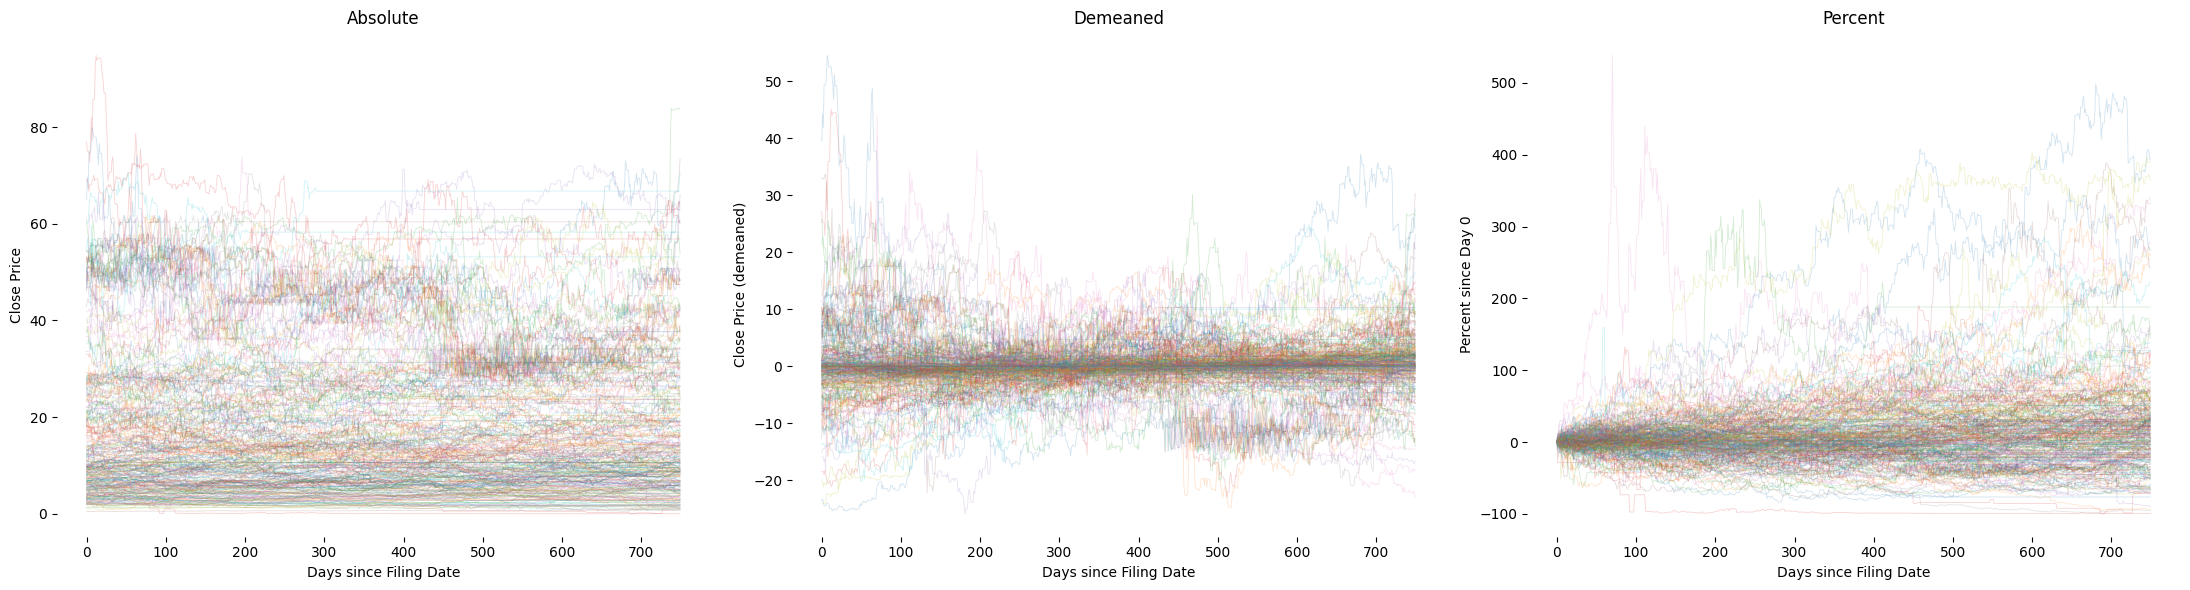

In [ ]:
day_cols = [str(i) for i in range(750)]

df_numeric = df[day_cols]
Q1 = df_numeric.quantile(0.25)
Q3 = df_numeric.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

mask = ~((df_numeric < lower) | (df_numeric > upper)).any(axis=1)
df_numeric = df_numeric[mask]

# data is to large, plot only a n=300 sample
sample = df_numeric.sample(n=300, random_state=69)

# with matrix else warning
abs_mat = sample[day_cols].to_numpy(dtype=float)

row_mean = np.nanmean(abs_mat, axis=1, keepdims=True)
demean_mat = abs_mat - row_mean

ref = sample[day_cols[0]].to_numpy(dtype=float)[:, None]
ref = np.where(ref == 0, np.nan, ref)
percent_mat = ((abs_mat - ref) / ref)*100

x = np.arange(750)

fig, axs = plt.subplots(1, 3, figsize=(22, 6), sharex=True)

axs[0].plot(x, abs_mat.T, linewidth=0.6, alpha=0.2)
axs[0].set_title('Absolute')
axs[0].set_xlabel('Days since Filing Date')
axs[0].set_ylabel('Close Price')

axs[1].plot(x, demean_mat.T, linewidth=0.6, alpha=0.2)
axs[1].set_title('Demeaned')
axs[1].set_xlabel('Days since Filing Date')
axs[1].set_ylabel('Close Price (demeaned)')

axs[2].plot(x, percent_mat.T, linewidth=0.6, alpha=0.2)
axs[2].set_title('Percent')
axs[2].set_xlabel('Days since Filing Date')
axs[2].set_ylabel('Percent since Day 0')

for ax in axs:
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout()
plt.savefig(project_root/ 'exports/close_random_300.png', dpi=500)
plt.show()

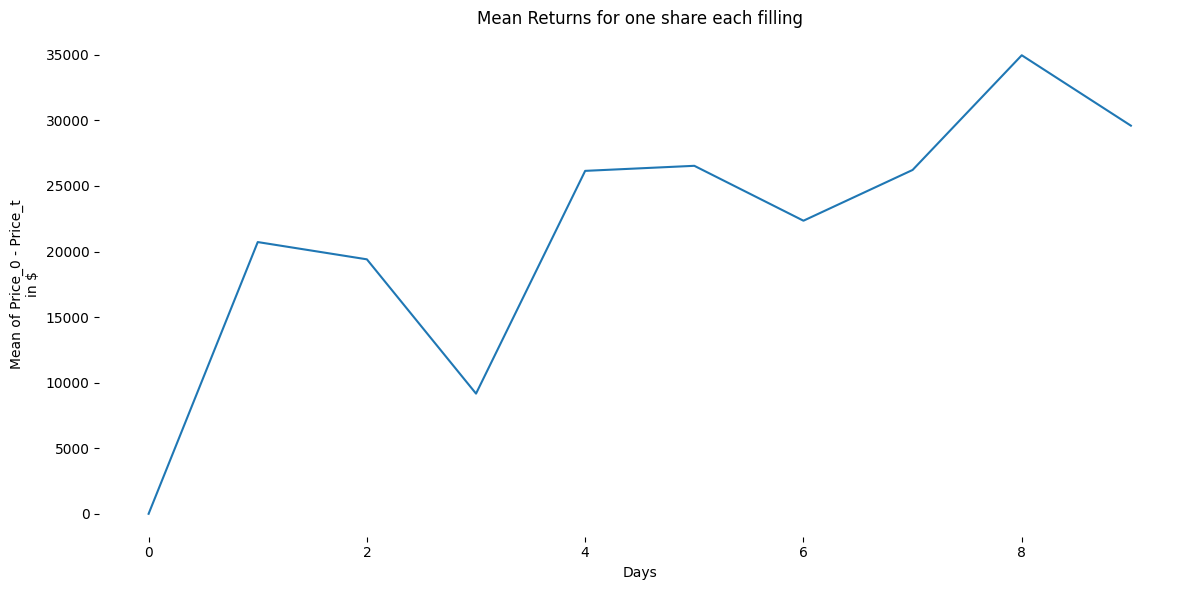

In [3]:
x_0 = df['0'].to_numpy()[:, None]
day_cols = [str(i) for i in range(10)]
Xt = df[day_cols].to_numpy()
return_matrix = Xt - x_0
return_df = pd.DataFrame(return_matrix)
mean_return = return_df.mean()

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

ax.plot(mean_return)
ax.set_title('Mean Returns for one share each filling')
ax.set_xlabel('Days')
ax.set_ylabel('Mean of Price_0 - Price_t\nin $')
ax.ticklabel_format(style='plain', axis='y')
for s in ax.spines.values():
    s.set_visible(False)

plt.tight_layout()
plt.savefig(project_root / 'exports/mean_return_10d.png', dpi=500)
plt.show()

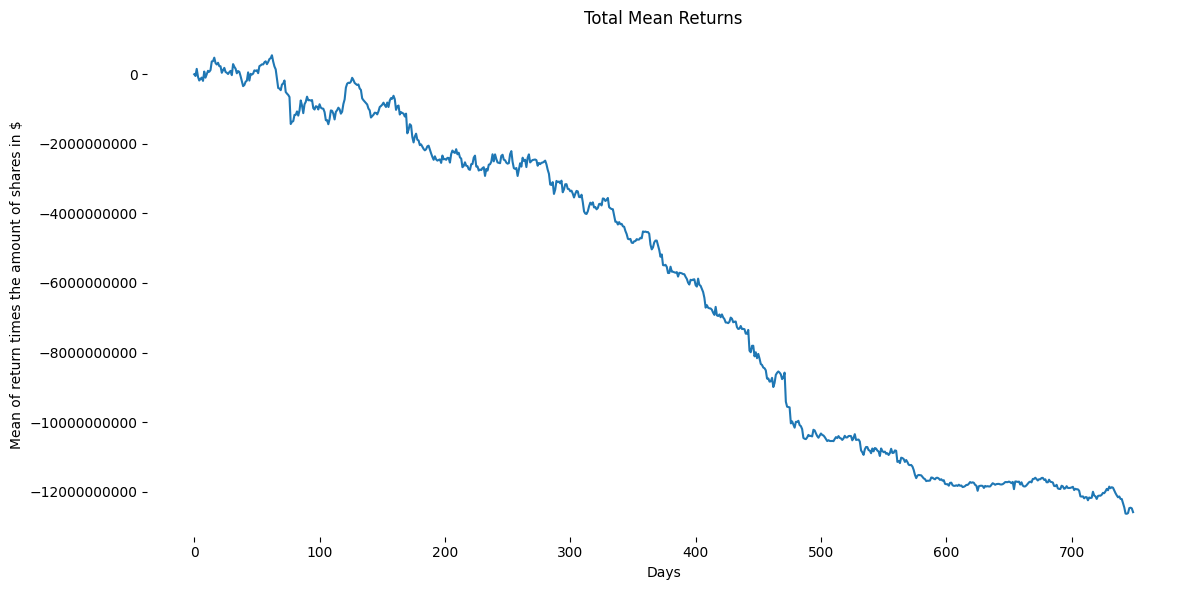

In [ ]:
n = df['amounts.shares'].to_numpy()[:, None]
x_0 = df['0'].to_numpy()[:, None]
day_cols = [str(i) for i in range(750)]
Xt = df[day_cols].to_numpy()
return_matrix = (Xt - x_0)*n
return_df = pd.DataFrame(return_matrix)
mean_return = return_df.mean()

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

ax.plot(mean_return)
ax.set_title('Total Mean Returns')
ax.set_xlabel('Days')
ax.set_ylabel('Mean of return times the amount of shares in $')
ax.ticklabel_format(style='plain', axis='y')
for s in ax.spines.values():
    s.set_visible(False)

plt.tight_layout()
plt.savefig(project_root / 'exports/mean_of_return_times_the_amount_of_shares_2y.png', dpi=500)
plt.show()

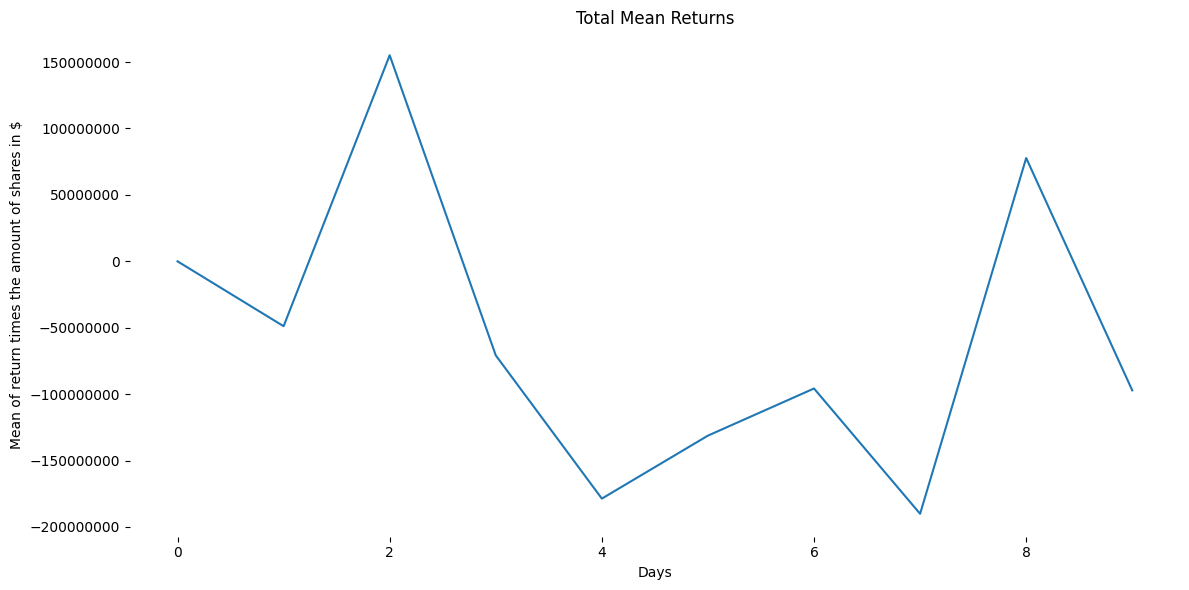

In [ ]:
n = df['amounts.shares'].to_numpy()[:, None]
x_0 = df['0'].to_numpy()[:, None]
day_cols = [str(i) for i in range(10)]
Xt = df[day_cols].to_numpy()
return_matrix = (Xt - x_0)*n
return_df = pd.DataFrame(return_matrix)
mean_return = return_df.mean()

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

ax.plot(mean_return)
ax.set_title('Total Mean Returns')
ax.set_xlabel('Days')
ax.set_ylabel('Mean of return times the amount of shares in $')
ax.ticklabel_format(style='plain', axis='y')
for s in ax.spines.values():
    s.set_visible(False)

plt.tight_layout()
plt.savefig(project_root / 'exports/mean_of_return_times_the_amount_of_shares_10d.png', dpi=500)
plt.show()

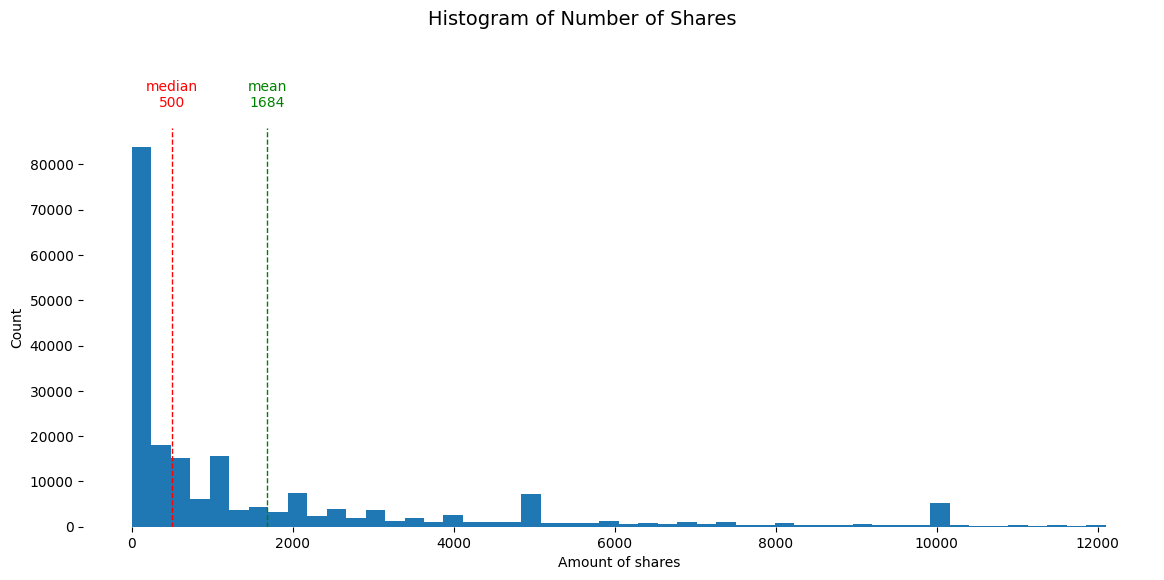

In [ ]:
shares = df["amounts.shares"]
Q1 = shares.quantile(0.25)
Q3 = shares.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

mask = (shares >= lower) & (shares <= upper)
shares = shares[mask]

fig, ax = plt.subplots(1, 1, figsize=(12, 6))
fig.suptitle("Histogram of Number of Shares", fontsize=14)
ax.hist(shares, bins=50)
ax.set_xlabel('Amount of shares')
ax.set_ylabel('Count')

median = shares.median()

for s in ax.spines.values():
    s.set_visible(False)
ax.axvline(median, linestyle="--", lw=1, c="red")
ax.text(median,
        ax.get_ylim()[1]*+1.12,
        f"median\n{median:.0f}",
        va="top",
        ha="center",
        color="red")

mean = shares.mean()

for s in ax.spines.values():
    s.set_visible(False)
ax.axvline(mean, linestyle="--", lw=1, c="green")
ax.text(mean,
        ax.get_ylim()[1]*+1.12,
        f"mean\n{mean:.0f}",
        va="top",
        ha="center",
        color="green")

plt.tight_layout(pad=2.0, w_pad=1.0, h_pad=2.0)
plt.savefig(project_root / 'exports/histogram_of_number_of_shares.png', dpi=500)
plt.show()